In [2]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import medfilt 
import scipy.ndimage
from scipy.ndimage import median_filter
import random
import matplotlib.pyplot as plt
import csv

# Normal Median Filtered Histogram 

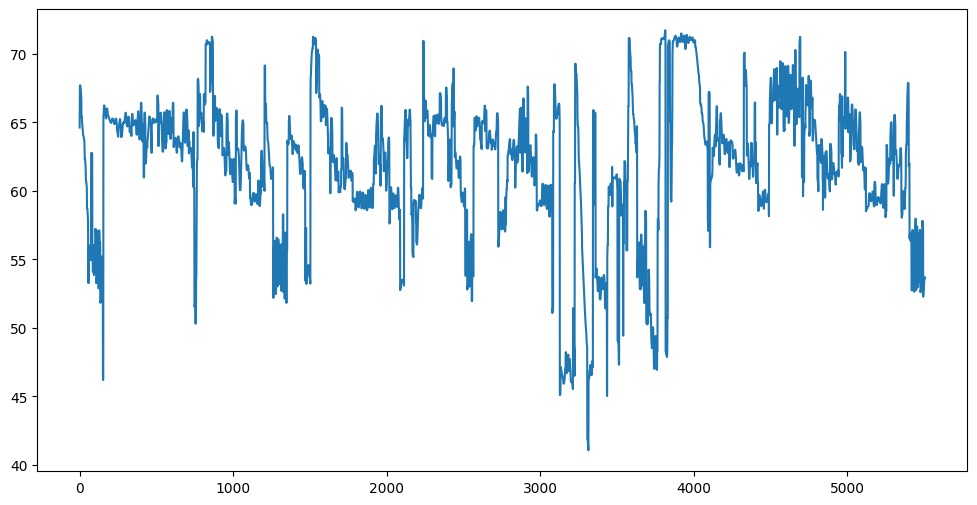

In [15]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

def apply_median_filter(f0_series, kernel_size=5):
    f0_series = np.where(np.isnan(f0_series), 0, f0_series)
    filtered_f0 = medfilt(f0_series, kernel_size = kernel_size)
    filtered_f0[filtered_f0 == 0] = np.nan
    return filtered_f0

file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/06 적벽가 중 장승타령에서부터 관운장 나오는데까지3(계면).csv'

df = pd.read_csv(file_path, header = None)

df.columns = ['Time', 'F0', 'Confidence']
df.loc[df['Confidence'] <= 0.7, "F0"] = np.nan
f0_values = apply_median_filter(df["F0"].values)
valid_f0_values = f0_values[~np.isnan(f0_values)]
midi_notes = f0_to_midi(valid_f0_values) 

lower_bound = 41
upper_bound = 72

midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

plt.figure(figsize=(12, 6))
plt.plot(midi_notes)
plt.show()

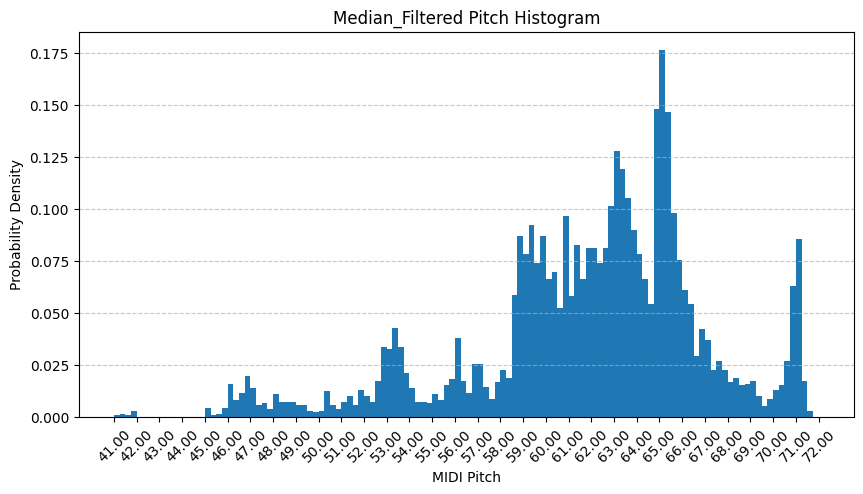

In [17]:
def get_norm_pitch_histogram(midi_notes, bin_size=0.25):
    edges = np.arange(41, 72 + bin_size, bin_size) 
    hist, _ = np.histogram(midi_notes, bins=edges, density=True)
    return hist, edges

hist, edges = get_norm_pitch_histogram(midi_notes)

bin_centers = (edges[:-1] + edges[1:]) / 2 

plt.figure(figsize=(10, 5))
plt.bar(bin_centers, hist, width=0.25, align='center')
plt.xticks(edges[::4], labels=[f"{e:.2f}" for e in edges[::4]], rotation=45)  
plt.xlabel("MIDI Pitch")
plt.ylabel("Probability Density")
plt.title("Median_Filtered Pitch Histogram")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



# Morphological Histogram

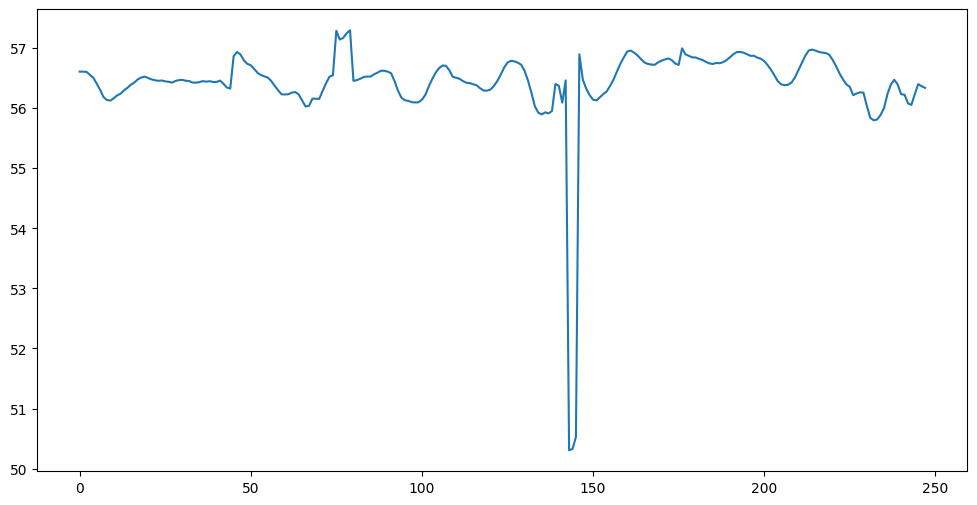

In [5]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/morph_filtered.csv'
df = pd.read_csv(file_path, header = None)

df.columns = ['F0', 'Time']
f0_values = df["F0"].values
valid_f0_values = f0_values[~np.isnan(f0_values)]
midi_notes = f0_to_midi(valid_f0_values) 

lower_bound = 41
upper_bound = 72

midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

plt.figure(figsize=(12, 6))
plt.plot(midi_notes)
plt.show()

Normalized Pitch Histogram: (array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.03225806, 0.01612903, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.16129032, 0.64516129,
       1.33870968, 0.88709677, 0.83870968, 0.0483871 , 0.03225806,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

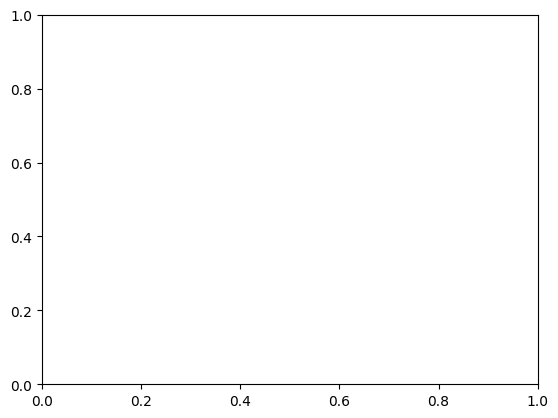

In [6]:
test = get_norm_pitch_histogram(midi_notes)

print("Normalized Pitch Histogram:", test)

plt.bar(range(len(test)), test, tick_label=[f"{-12 + i}" for i in range(25)])
plt.xlabel("Semitone Interval (Relative to Tonic)")
plt.ylabel("Probability Density")
plt.title("Morph-Filtered Pitch Histogram")
plt.show()

# Mask Filtered Histogram

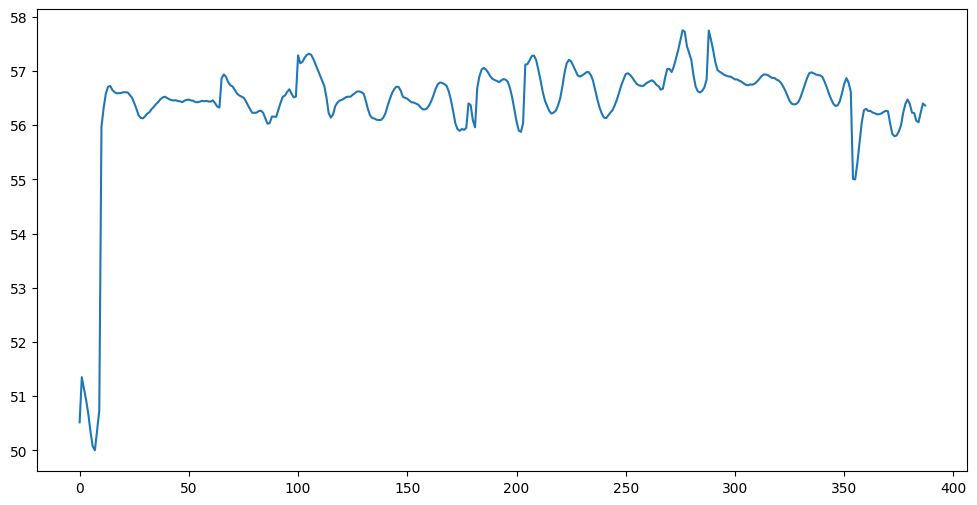

In [9]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/mask_filtered.csv'
df = pd.read_csv(file_path, header = None)

df.columns = ['F0', 'Time']
f0_values = df["F0"].values
valid_f0_values = f0_values[~np.isnan(f0_values)]
midi_notes = f0_to_midi(valid_f0_values) 

lower_bound = 41
upper_bound = 72

midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

plt.figure(figsize=(12, 6))
plt.plot(midi_notes)
plt.show()

Normalized Pitch Histogram: [0.         0.         0.         0.         0.         0.
 0.02061856 0.00515464 0.         0.         0.00257732 0.04381443
 0.82216495 0.1056701  0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.        ]


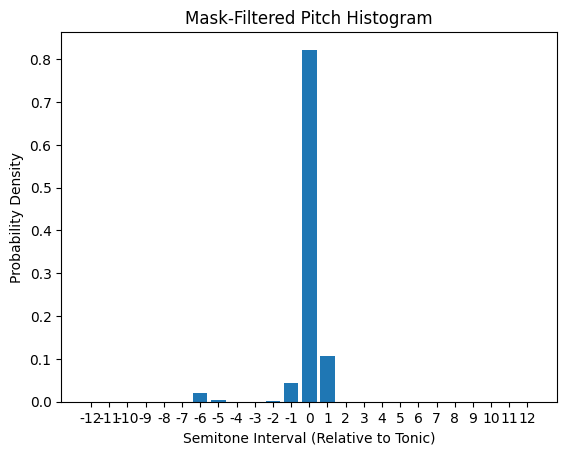

In [ ]:
def get_norm_pitch_histogram(midi_contour):
    edge = [i + (-12.5) for i in range(26)]
    comp = 0
    final_common_midi = 0

    norm_midi = [midi-float(final_common_midi-comp) for midi in midi_contour]
    mono_hist = np.histogram(norm_midi, bins = edge, density=True)
    
    return mono_hist[0]

test = get_norm_pitch_histogram(midi_notes)

print("Normalized Pitch Histogram:", test)

plt.bar(range(len(test)), test, tick_label=[f"{-12 + i}" for i in range(25)])
plt.xlabel("Semitone Interval (Relative to Tonic)")
plt.ylabel("Probability Density")
plt.title("Mask-Filtered Pitch Histogram")
plt.show()


def get_norm_pitch_histogram(midi_notes, bin_size=0.25):

    edges = np.arange(45, 65 + bin_size, bin_size) 
    hist, _ = np.histogram(midi_notes, bins=edges, density=True)
    return hist, edges

test, edges = get_norm_pitch_histogram(midi_notes)